In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [9]:
survey_1 = [35, 36, 33, 37, 34, 35]
n1 = len(survey_1)
np.mean(survey_1)

35.0

In [10]:
survey_2 = [20, 37, 17, 50, 53, 33]
n2 = len(survey_2)
np.mean(survey_2)

35.0

In [6]:
## Sampling with replacement
names = ["Anil", "Faruk", "Shantala"]
np.random.choice(names, size = 10)

array(['Anil', 'Shantala', 'Anil', 'Shantala', 'Anil', 'Faruk',
       'Shantala', 'Shantala', 'Anil', 'Anil'], dtype='<U8')

In [23]:
bootstrapped_samples = np.random.choice(survey_1, size = n1)
print(bootstrapped_samples)
print(np.mean(bootstrapped_samples))

[35 35 33 34 35 37]
34.833333333333336


### The sample mean is a random variable!!!!

### Estimate C.I. for Survey 1

In [34]:
bootstrap_survey_1 = []
for reps in range(100000):
    bootstrapped_sample = np.random.choice(survey_1, size = n1)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrap_survey_1.append(bootstrapped_mean)

<AxesSubplot:ylabel='Count'>

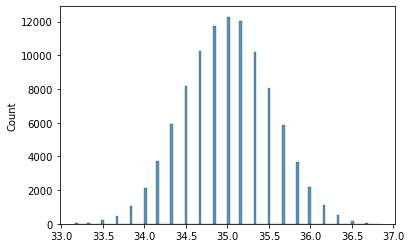

In [36]:
sns.histplot(bootstrap_survey_1)

In [38]:
np.std(bootstrap_survey_1)

0.5271701932619947

In [39]:
bootstrap_survey_1[4654]

35.5

In [40]:
left = np.percentile(bootstrap_survey_1, 2.5)
right = np.percentile(bootstrap_survey_1, 97.5)

print(f"With 95% confidence, the mean SDE2 salary lies between [{left}, {right}]")

With 95% confidence, the mean SDE2 salary lies between [34.0, 36.0]


### Estimate C.I. for Survey 2

In [41]:
bootstrap_survey_2 = []
for reps in range(100000):
    bootstrapped_sample = np.random.choice(survey_2, size = n2)
    bootstrapped_mean = np.mean(bootstrapped_sample)
    bootstrap_survey_2.append(bootstrapped_mean)

<AxesSubplot:ylabel='Count'>

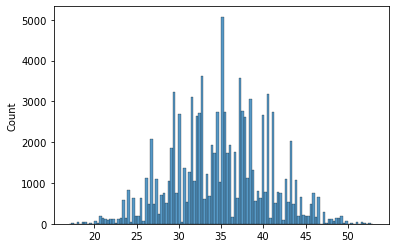

In [45]:
sns.histplot(bootstrap_survey_2)

In [46]:
left  = np.percentile(bootstrap_survey_2, 2.5)
right = np.percentile(bootstrap_survey_2, 97.5)

print(f"With 95% confidence, the mean SDE2 salary lies between [{left}, {right}]")

With 95% confidence, the mean SDE2 salary lies between [24.0, 46.0]


### Sehwag's data

In [47]:
import pandas as pd

In [48]:
sehwag = pd.read_csv("sehwag.csv")
sehwag.head()

,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Unnamed: 9,Opposition,Ground,Start Date,Unnamed: 13
0,1,5,2,0,0,50.00,7,lbw,1,NaN,v Pakistan,Mohali,1 Apr 1999,ODI # 1427
1,19,18,24,0,1,79.16,6,caught,1,NaN,v Zimbabwe,Rajkot,14 Dec 2000,ODI # 1660
2,58,62,54,8,0,107.40,6,bowled,1,NaN,v Australia,Bengaluru,25 Mar 2001,ODI # 1696
3,2,7,7,0,0,28.57,6,caught,2,NaN,v Zimbabwe,Bulawayo,27 Jun 2001,ODI # 1730
4,11,19,16,1,0,68.75,6,not out,2,NaN,v West Indies,Bulawayo,30 Jun 2001,ODI # 1731


### What are we doing here?
With a small sample size, we want to estimate his average runs.

In [49]:
len(sehwag)

245

### Since we have the whole population with us, we can get the population mean and population std directly!!

In [51]:
sehwag.describe()

,Runs,BF,4s,6s,SR,Pos,Inns,Unnamed: 9
count,245.000000,245.000000,245.000000,245.000000,245.000000,245.00000,245.000000,0.0
mean,33.767347,32.363265,4.620408,0.555102,93.085755,1.82449,1.530612,NaN
std,34.809419,29.175744,4.583335,1.124442,46.830716,1.24376,0.500084,NaN
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.00000,1.000000,NaN
25%,8.000000,10.000000,1.000000,0.000000,65.850000,1.00000,1.000000,NaN
50%,23.000000,25.000000,3.000000,0.000000,92.230000,1.00000,2.000000,NaN
75%,46.000000,42.000000,7.000000,1.000000,123.800000,2.00000,2.000000,NaN
max,219.000000,149.000000,25.000000,7.000000,260.000000,8.00000,2.000000,NaN


In [90]:
pop_mu = sehwag["Runs"].mean()
pop_sigma = sehwag["Runs"].std()

### Sampling Sehwag's data

In [67]:
num_samples = 20

In [76]:
sehwag_samples = sehwag["Runs"].sample(num_samples)
print("Sample mean: ", sehwag_samples.mean())
print("Sample var: ", sehwag_samples.var())

Sample mean:  46.05
Sample var:  1184.2605263157898


In [77]:
sehwag_samples = sehwag["Runs"].sample(num_samples)
print("Sample mean: ", sehwag_samples.mean())
print("Sample var: ", sehwag_samples.var())

Sample mean:  36.5
Sample var:  1033.6315789473683


### Since the variance in the sample mean seems to reduce with the sample size, let's see how one affects the other

Text(0, 0.5, 'Sample mean')

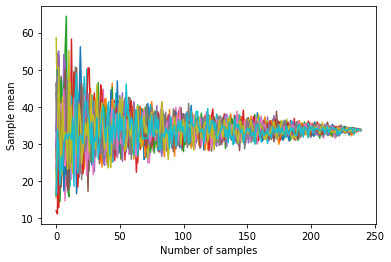

In [81]:
sample_mean_trend = []
for person in range(20):
    for num_samples in range(5, len(sehwag)):
        sample = sehwag["Runs"].sample(num_samples)
        sample_mean = np.mean(sample)
        sample_mean_trend.append(sample_mean)
    plt.plot(sample_mean_trend)
    sample_mean_trend = []
plt.xlabel("Number of samples")
plt.ylabel("Sample mean")

### Sample mean histogram

(10.0, 60.0)

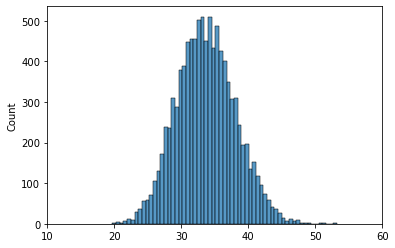

In [85]:
num_samples = 50
num_people = 10000
sample_means = []
for person in range(num_people):
    sample = sehwag["Runs"].sample(num_samples)
    sample_mean = np.mean(sample)
    sample_means.append(sample_mean)
sns.histplot(sample_means)
plt.xlim([10, 60])

(10.0, 60.0)

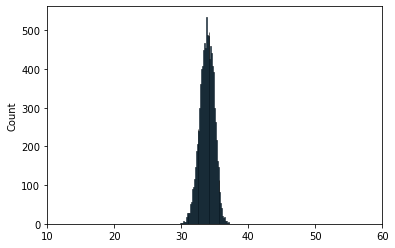

In [86]:
num_samples = 200
num_people = 10000
sample_means = []
for person in range(num_people):
    sample = sehwag["Runs"].sample(num_samples)
    sample_mean = np.mean(sample)
    sample_means.append(sample_mean)
sns.histplot(sample_means)
plt.xlim([10, 60])

In [88]:
from scipy.stats import norm
left_z = round(norm.ppf(0.025), 2)
right_z = round(norm.ppf(0.975), 2)

print(f"Range of z values: [{left_z}, {right_z}]")

Range of z values: [-1.96, 1.96]


In [93]:
obs_mean = sample_means[-1]

left = left_z * pop_sigma/np.sqrt(num_samples) + obs_mean
right = right_z * pop_sigma/np.sqrt(num_samples) + obs_mean

print(f"With 95% confidence interval, we can say that {obs_mean} lies between [{left}, {right}]")

With 95% confidence interval, we can say that 33.385 lies between [28.56066066087631, 38.20933933912369]
